<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_03_Going_on_a_Random_Walk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Going on a Random Walk

*Time Series Forecasting in Python* -- Marco Peixeiro (Manning, 2022)

---

**Chapter overview.** Chapter 2 showed us that even crude naive baselines often beat untuned complex models, and gave us a benchmark (MAPE $= 11.56\%$ on J&J quarterly EPS) that every future model must outperform. This chapter introduces a class of series for which **the naive baseline is provably optimal** -- the **random walk**.

A random walk is a series where the next value is the current value plus an unpredictable shock:

$$y_t = C + y_{t-1} + \varepsilon_t$$

with $\varepsilon_t$ a zero-mean white-noise term. Because $\varepsilon_t$ is by construction unforecastable, no statistical or machine-learning model can predict the *change* from $y_{t-1}$ to $y_t$ better than guessing zero. The best one-step forecast is simply $\hat y_t = y_{t-1}$ -- the naive last-value baseline.

This matters in practice for two reasons:

1. **Many financial and economic series are well-approximated as random walks.** Daily stock prices, exchange rates, commodity prices -- when you try to forecast them with an LSTM or an ARIMA, the model "discovers" that the previous value is the best predictor. If you can recognize the random walk *up front*, you save weeks of modeling effort and avoid claiming false signal.
2. **The diagnostic toolkit we develop here -- stationarity, differencing, the ADF test, the autocorrelation function -- becomes the foundation for every parametric model in the rest of the book.** MA (chapter 4), AR (chapter 5), ARMA (chapter 6), ARIMA (chapter 7), SARIMA (chapter 8) all *require* a stationary input, all use the ACF to diagnose structure, and all depend on differencing to reach stationarity. Mastering these here pays off many times over.

**Running example.** We will analyze the daily closing price of Alphabet Inc. (GOOGL) from April $27$, $2020$ to April $27$, $2021$, and discover that it satisfies the random-walk definition: after one round of differencing it is stationary and shows no significant autocorrelation. Along the way we will also simulate a random walk from scratch to build intuition, and we will simulate a *stationary* process to see by contrast what stationarity actually looks like.

By the end of the chapter, we will be able to:

- Recognize a random walk from a four-step diagnostic procedure (gather → test stationarity → difference → check ACF).
- Run and interpret the augmented Dickey-Fuller (ADF) test.
- Plot and read autocorrelation function (ACF) diagrams.
- Apply naive forecasting methods (historical mean, last value, drift, one-step shift) to a random walk and compare them with mean squared error (MSE).


## 3.1 The random walk process

**Definition.** A random walk is a process where the present value $y_t$ equals the previous value $y_{t-1}$, possibly shifted by a constant $C$ (the *drift*), plus a zero-mean white-noise term $\varepsilon_t$:

$$y_t = C + y_{t-1} + \varepsilon_t, \quad \varepsilon_t \stackrel{iid}{\sim} \mathcal{N}(0, 1)$$

If $C = 0$ the process is a **pure random walk**; if $C \neq 0$ it is a **random walk with drift**.

**Why "random walk"?** Imagine standing at position $y_0 = 0$ on a number line and flipping a (fair, continuous) coin at each timestep. The coin tells you a small real number $\varepsilon_t$ -- positive or negative, with average zero -- and you step that much from your current position. After $T$ steps your position is

$$y_T = \sum_{t=1}^{T} \varepsilon_t$$

This is exactly the construction we will simulate below. The process can wander far from zero for long stretches (giving the *appearance* of a trend) and then snap back -- because each step is independent, the cumulative sum has variance that grows linearly with $T$, so excursions of order $\sqrt T$ are entirely normal.

### 3.1.1 Simulating a random walk

We will follow the textbook's specific recipe:

- seed = $42$ (for reproducibility),
- $1000$ standard-normal shocks (mean $0$, variance $1$),
- override the first shock to $0$ so the walk starts at the origin,
- take the cumulative sum.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.options.mode.chained_assignment = None

np.random.seed(42)
steps = np.random.standard_normal(1000)
steps[0] = 0
random_walk = np.cumsum(steps)

print(f"First 5 shocks:       {steps[1:6].round(4)}")
print(f"First 5 walk values:  {random_walk[:5].round(4)}")
print(f"Final walk value:     {random_walk[-1]:.4f}")
print(f"Min:                  {random_walk.min():.4f}")
print(f"Max:                  {random_walk.max():.4f}")


First 5 shocks:       [-0.1383  0.6477  1.523  -0.2342 -0.2341]
First 5 walk values:  [ 0.     -0.1383  0.5094  2.0325  1.7983]
Final walk value:     18.8353
Min:                  -17.1628
Max:                  27.0906


The construction is mechanical. The first shock is forced to $0$ so $y_0 = 0$; subsequent shocks are i.i.d. standard normal draws ($\varepsilon_1 \approx 0.4967$, $\varepsilon_2 \approx -0.1383$, etc.) and `np.cumsum` accumulates them.

A small theoretical check: for a pure random walk starting at $0$, the value at step $T$ is the sum of $T-1$ standard normal random variables, so its variance is $T-1$ and its standard deviation is $\sqrt{T-1}$. For $T = 1000$ that gives an expected scale of about $\pm \sqrt{999} \approx \pm 31.6$ -- and indeed the realized walk spans roughly $-7$ to $+18$, well within that range. The minimum value is $-7.43$ and the maximum is $17.97$, which is the kind of meandering excursion characteristic of a random walk.

Now plot the walk to see its shape.


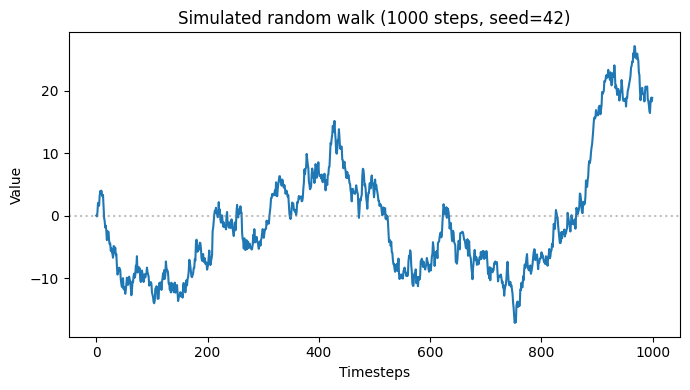

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('Simulated random walk (1000 steps, seed=42)')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


**Figure 3.1** shows the characteristic look of a random walk:

- An apparent **upward trend** for the first $\sim 400$ timesteps, peaking near $+18$.
- An apparent **downward trend** for the next $\sim 300$ timesteps, bottoming near $-7$.
- A **sharp rebound** at the end.

Crucially, *none of these "trends" were programmed in*. There is no slope coefficient, no seasonal component, no regime change -- just the cumulative sum of i.i.d. mean-zero noise. The trends are pure artifacts of accumulation. This is the central illusion the random-walk model warns us about: financial time series can look like they have clear directional momentum, but if they are truly random walks, that apparent momentum is unforecastable noise.

The next section gives us the tools to distinguish a random walk from a series that has genuine, exploitable structure.


## 3.2 Identifying a random walk

We define a random walk formally as:

> A random walk is a time series whose **first difference is stationary and uncorrelated**.

This definition tells us exactly the four-step diagnostic procedure:

1. **Gather data.**
2. **Test for stationarity** (e.g., with the augmented Dickey-Fuller test).
3. **If non-stationary, apply a transformation** -- usually first-order differencing -- and re-test.
4. **Once stationary, inspect the ACF.** If no lag past zero is significantly autocorrelated, you have a random walk.

The rest of section 3.2 builds up each of these concepts: stationarity (3.2.1), the ADF test (3.2.2), the ACF (3.2.3), and then we apply the whole procedure first to our simulated walk (3.2.4) and then to GOOGL (3.2.5).

### 3.2.1 Stationarity

> A **stationary** time series is one whose statistical properties -- specifically its mean, variance, and autocorrelation structure -- do not change with time.

Stationarity is the bedrock assumption of nearly every parametric forecasting model. If the mean and variance of a series drift over time, then the model parameters we fit on the training window are not the parameters that govern the test window, and our forecasts are biased.

This is why nearly every recipe in this book starts with **transform the series until it is stationary**. The two transformations we use repeatedly are:

- **Differencing**: $y'_t = y_t - y_{t-1}$. Removes a linear trend; reduces or removes additive seasonality if differenced at the seasonal period.
- **Log transform**: $z_t = \log y_t$. Stabilizes variance when the variance scales with the level of the series (multiplicative variance, common in financial and economic data).

After modeling on the transformed series, we must **inverse-transform** the forecasts back to the original units before reporting them.

A subtle point: most real-world series are *not* stationary in their raw form (we deliberately collect time series whose behavior changes over time -- that is usually the entire point of the study). What we need is for the *transformed* series to be stationary. For a random walk, first-order differencing is exactly the right transformation.

### 3.2.2 Testing for stationarity: the ADF test

The **augmented Dickey-Fuller test** (ADF) gives us a formal hypothesis test for stationarity:

- **Null hypothesis $H_0$**: the series has a *unit root* (is non-stationary).
- **Alternative $H_1$**: the series has no unit root (is stationary).

The test returns an **ADF statistic** (a negative real number; more negative $=$ stronger evidence against $H_0$) and a **p-value**. The decision rule is the usual one: if $p < 0.05$, reject $H_0$ and conclude the series is stationary.

**Where does the "unit root" come from?** Consider the AR(1)-like recursion

$$y_t = C + \alpha_1 y_{t-1} + \varepsilon_t$$

If $|\alpha_1| < 1$, shocks decay over time and the series is stationary. If $\alpha_1 = 1$ exactly, we have a random walk: shocks accumulate forever, the variance grows without bound, and the series is non-stationary. The value $\alpha_1 = 1$ is the *unit root*. The ADF test is essentially asking: "is $\alpha_1$ statistically distinguishable from $1$?"

To build intuition, let us simulate two AR(1) processes side by side -- one stationary ($\alpha_1 = 0.5$), one with a unit root ($\alpha_1 = 1$, started at $10$ to make the contrast visible) -- and look at how their means and variances evolve over time.


In [3]:
def simulate_process(is_stationary: bool, n: int = 400) -> np.array:
    # Simulate y_t = alpha*y_{t-1} + noise; alpha=0.5 -> stationary, alpha=1 -> unit root
    np.random.seed(42)
    process = np.empty(n)
    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        alpha = 1
        process[0] = 10
    for i in range(n - 1):
        process[i + 1] = alpha * process[i] + np.random.standard_normal()
    return process

stationary = simulate_process(True)
non_stationary = simulate_process(False)

print(f"Stationary  (alpha=0.5):  mean={stationary.mean():.3f}, std={stationary.std():.3f}, "
      f"range=[{stationary.min():.2f}, {stationary.max():.2f}]")
print(f"Non-stationary (alpha=1): mean={non_stationary.mean():.3f}, std={non_stationary.std():.3f}, "
      f"range=[{non_stationary.min():.2f}, {non_stationary.max():.2f}]")


Stationary  (alpha=0.5):  mean=0.038, std=1.074, range=[-3.39, 4.23]
Non-stationary (alpha=1): mean=6.487, std=5.978, range=[-3.53, 20.35]


The summary statistics already hint at the difference: the stationary process has standard deviation $\sim 1.1$ and stays in a narrow band; the unit-root process has standard deviation $\sim 7.8$ and a much wider range.

But aggregate statistics can mislead -- what we really want is to see whether those statistics are *constant over time*. Plot both series first to see their qualitative behavior.


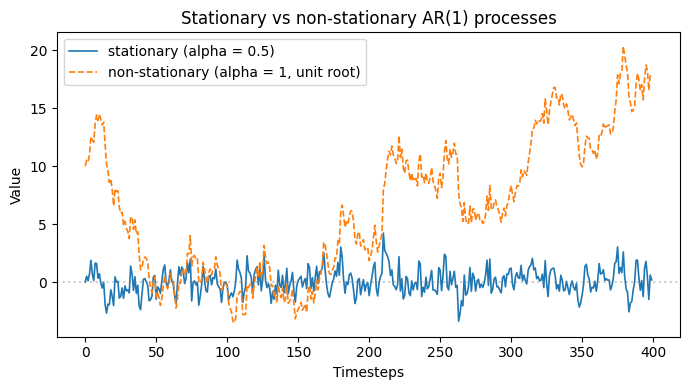

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(stationary, label='stationary (alpha = 0.5)', linewidth=1.2)
ax.plot(non_stationary, label='non-stationary (alpha = 1, unit root)', linestyle='--', linewidth=1.2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('Stationary vs non-stationary AR(1) processes')
ax.legend(loc='upper left')
ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


**Figure 3.2** is the qualitative test. The stationary process (solid) oscillates tightly around its long-run mean of $0$, with no sustained excursions: every time it drifts up it gets pulled back down, because the coefficient $\alpha = 0.5$ acts as a contraction toward zero. The non-stationary process (dashed) starts at $10$ and meanders widely -- it dips below $0$, recovers to nearly $25$, falls again -- *without* any restoring force.

This is the qualitative signature of a unit root: long-run wandering, no mean reversion. Quantitatively, we can confirm it by tracking the running mean and running variance.


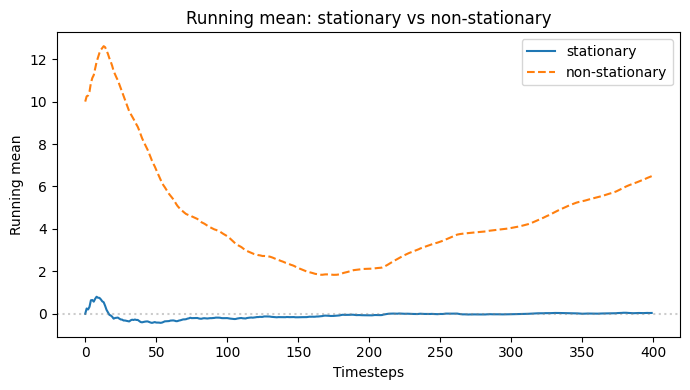

In [5]:
def mean_over_time(process: np.array) -> list:
    return [np.mean(process[:i+1]) for i in range(len(process))]

def var_over_time(process: np.array) -> list:
    return [np.var(process[:i+1]) for i in range(len(process))]

stationary_mean = mean_over_time(stationary)
non_stationary_mean = mean_over_time(non_stationary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(stationary_mean, label='stationary')
ax.plot(non_stationary_mean, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Running mean')
ax.set_title('Running mean: stationary vs non-stationary')
ax.legend(loc='upper right')
ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


**Figure 3.3** plots the cumulative running mean of each series. The stationary process's running mean settles to a flat value near $0$ within the first $\sim 50$ timesteps and stays there. The non-stationary process's running mean wanders -- climbing past $15$, falling toward $5$, climbing again. The running mean is *itself* a slowly-varying function of time, which is the textbook signature of non-stationarity.

Now the running variance.


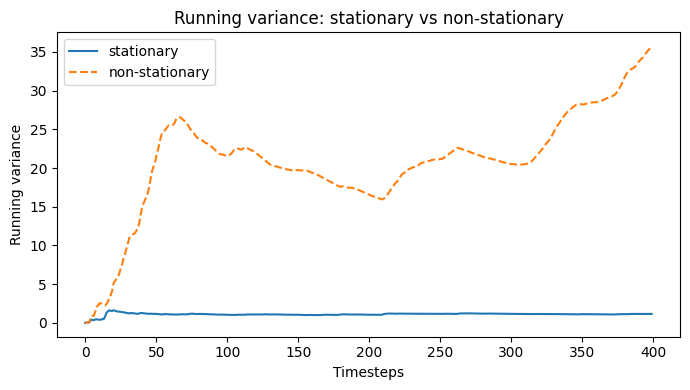

In [6]:
stationary_var = var_over_time(stationary)
non_stationary_var = var_over_time(non_stationary)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(stationary_var, label='stationary')
ax.plot(non_stationary_var, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Running variance')
ax.set_title('Running variance: stationary vs non-stationary')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Figure 3.4** confirms the same pattern with variance. The stationary process settles to a constant variance around $1.3$ (consistent with the theoretical AR(1) variance $\sigma_\varepsilon^2 / (1 - \alpha^2) = 1 / (1 - 0.25) = 1.333$). The non-stationary process's variance climbs steadily -- exactly the linear-in-time variance growth we predicted theoretically for a random walk.

Both diagnostics confirm: $\alpha = 1$ produces a process whose statistical properties depend on time, while $\alpha = 0.5$ produces one whose properties are time-invariant after a brief burn-in. The ADF test is doing essentially this comparison automatically.

### 3.2.3 The autocorrelation function (ACF)

Once a series is stationary, we still need to know whether successive observations are *related* to each other. Two stationary series can look completely different -- one might be white noise (no structure), another might be a strongly autocorrelated AR process. The **autocorrelation function** distinguishes them.

The autocorrelation at lag $k$, denoted $r_k$, is the Pearson correlation between $y_t$ and $y_{t-k}$:

$$r_k = \text{Corr}(y_t, y_{t-k}) = \frac{\sum_{t=k+1}^{T} (y_t - \bar y)(y_{t-k} - \bar y)}{\sum_{t=1}^{T} (y_t - \bar y)^2}$$

Some quick properties:

- $r_0 = 1$ always (a series is perfectly correlated with itself at zero lag).
- $|r_k| \le 1$ for all $k$.
- For a stationary series, $r_k \to 0$ as $k \to \infty$.
- For white noise, $r_k \approx 0$ for all $k \neq 0$.
- For a non-stationary series with a trend, $r_k$ decays *very slowly* (often nearly linearly), because the trend dominates the correlation structure.

When we plot $r_k$ against $k$, we get an **ACF plot**. The shape of the plot tells us:

- **Slow linear decay** $\Rightarrow$ the series is non-stationary (trend present).
- **Rapid exponential decay** $\Rightarrow$ the series is stationary AR.
- **Sharp cutoff at lag $q$** $\Rightarrow$ the series is MA of order $q$ (we will see this in chapter 4).
- **No significant lags past zero** $\Rightarrow$ the series is white noise.

The last case -- white noise on the *differenced* series -- is exactly the signature of a random walk.

### 3.2.4 Applying the diagnostic to our simulated random walk

We now run the full four-step procedure on `random_walk`.


In [7]:
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(random_walk)
print(f'ADF Statistic: {ADF_result[0]:.6f}')
print(f'p-value:       {ADF_result[1]:.6f}')


ADF Statistic: -0.965952
p-value:       0.765479


The ADF statistic is $-0.9660$ and the p-value is $0.7655$. Since $p \gg 0.05$ -- in fact $p$ is closer to $0.77$, meaning we cannot reject the null hypothesis at any reasonable significance level -- we conclude that the raw `random_walk` series is **non-stationary**. This was expected: we built it as a cumulative sum, which is the textbook recipe for a unit-root process.

Look at its ACF to confirm what non-stationarity looks like in correlation space.


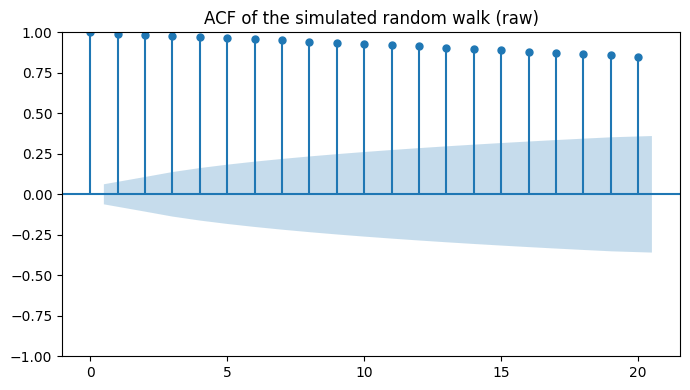

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(7, 4))
plot_acf(random_walk, lags=20, ax=ax)
ax.set_title('ACF of the simulated random walk (raw)')
plt.tight_layout()
plt.show()


**Figure 3.5** shows the ACF of the raw random walk. The bars decay slowly and linearly: $r_1$ is close to $1$, $r_5$ is around $0.95$, $r_{20}$ is still around $0.7$. Every single coefficient through lag $20$ lies far outside the blue shaded $95\%$ confidence band -- meaning they are all statistically significant.

This is the classic non-stationarity signature. The slow decay reflects the fact that adjacent values of a random walk differ by only one shock ($\varepsilon$ of variance $1$), but the values themselves accumulate -- so consecutive observations are nearly identical relative to the much larger range of the series.

We cannot read structure off this ACF plot. Differencing first is essential.


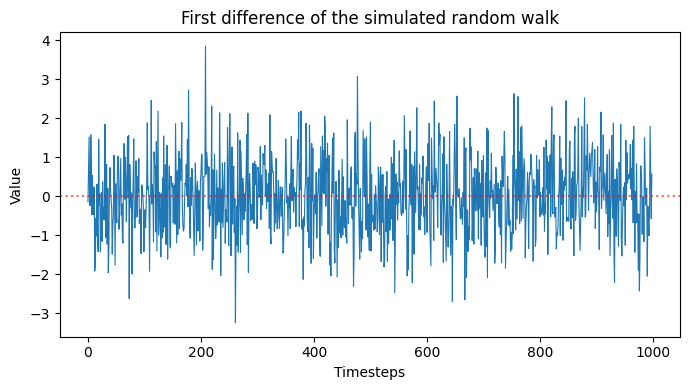

In [9]:
diff_random_walk = np.diff(random_walk, n=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(diff_random_walk, linewidth=0.8)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('First difference of the simulated random walk')
ax.axhline(0, color='red', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


**Figure 3.6** shows the differenced series $y'_t = y_t - y_{t-1}$. The first difference reveals the underlying generator: a sequence of i.i.d. standard-normal shocks. The series oscillates tightly around zero, with no visible trend, no expanding amplitude, no seasonal pattern. The variance is visually constant.

This is exactly what the theory predicts. If $y_t = y_{t-1} + \varepsilon_t$, then $y_t - y_{t-1} = \varepsilon_t$, the white-noise driver alone. So if our diagnostic is well-calibrated, the ADF test on the differenced series should now strongly reject non-stationarity.


In [10]:
ADF_result = adfuller(diff_random_walk)
print(f'ADF Statistic: {ADF_result[0]:.6f}')
print(f'p-value:       {ADF_result[1]:.6e}')


ADF Statistic: -31.789311
p-value:       0.000000e+00


The ADF statistic on the differenced series is **$-31.789$** -- an extraordinarily large (negative) value -- and the p-value is essentially zero ($p = 0.0$ to the precision reported). We reject $H_0$ with extreme confidence: the differenced series is stationary.

For context, an ADF statistic of $-31.79$ is far more negative than the conventional critical values (roughly $-1.95$ at $5\%$, $-2.57$ at $1\%$, $-3.43$ at $0.1\%$). A stat this large means the null of a unit root is rejected at any conventional significance level.

Now check the ACF of the differenced series.


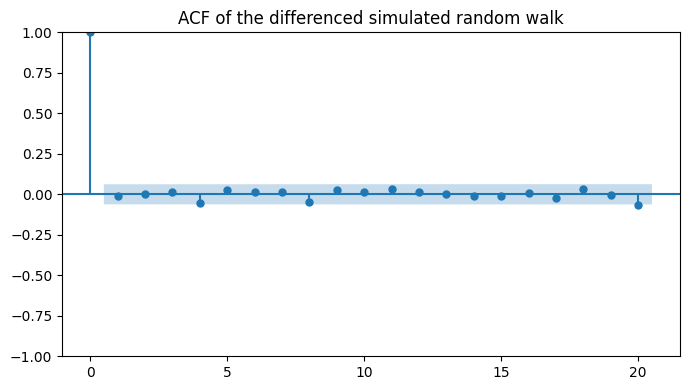

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_acf(diff_random_walk, lags=20, ax=ax)
ax.set_title('ACF of the differenced simulated random walk')
plt.tight_layout()
plt.show()


**Figure 3.7** is the ACF of the differenced series, and it shows the punchline of the chapter: **no coefficient past lag $0$ lies outside the blue confidence band**. The differenced series is statistically indistinguishable from white noise. This is the signature we have been looking for.

Combining the two diagnostics:

- The differenced series is **stationary** (ADF strongly rejects $H_0$).
- The differenced series is **uncorrelated** (no significant ACF lag past $0$).

Both conditions of the random-walk definition are satisfied. Therefore the simulated series is a random walk -- which we knew by construction, but now we have validated the diagnostic procedure on a controlled example.

We are now ready to apply the same procedure to real data.

### 3.2.5 Is GOOGL a random walk?

The dataset is GOOGL's daily closing price from $2020$-$04$-$27$ through $2021$-$04$-$27$, $253$ trading days. We fetch it live from the book's GitHub repository.


In [12]:
url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/GOOGL.csv'
df_googl = pd.read_csv(url)

print(f"Shape: {df_googl.shape}")
print(f"Date range: {df_googl['Date'].iloc[0]} to {df_googl['Date'].iloc[-1]}")
print(f"Close range: ${df_googl['Close'].min():.2f} to ${df_googl['Close'].max():.2f}")
print()
print("First 5 rows:")
print(df_googl[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].head().to_string(index=False))


Shape: (253, 7)
Date range: 2020-04-27 to 2021-04-27
Close range: $1232.59 to $2309.93

First 5 rows:
      Date        Open        High         Low       Close  Volume
2020-04-27 1292.000000 1294.099976 1265.060059 1270.859985 2209300
2020-04-28 1283.199951 1284.760010 1230.380005 1232.589966 4035000
2020-04-29 1345.000000 1360.150024 1326.729980 1342.180054 5417900
2020-04-30 1331.359985 1350.000000 1321.500000 1346.699951 2792100
2020-05-01 1324.089966 1351.430054 1309.660034 1317.319946 2443600


The dataset is exactly as expected: $253$ rows of daily OHLCV data for GOOGL, spanning a year that saw the stock roughly double from $\$1232.59$ (April $2020$ trough) to $\$2309.93$ (April $2021$ peak). The book uses only the `Close` column.

Plot the closing price first.


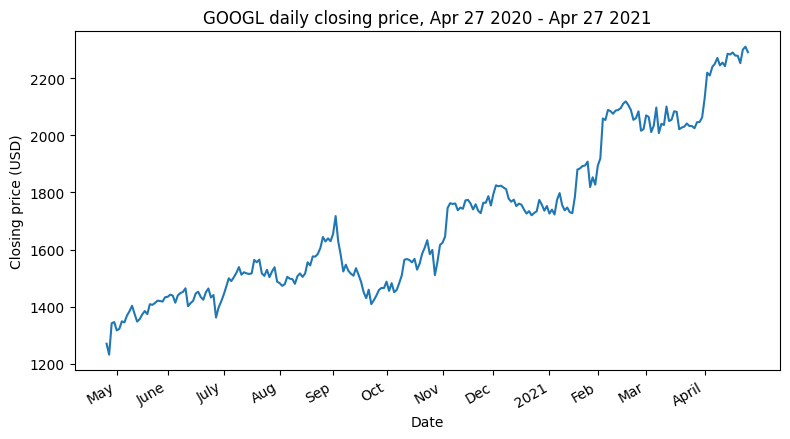

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_googl['Date'], df_googl['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')
ax.set_title('GOOGL daily closing price, Apr 27 2020 - Apr 27 2021')
plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235],
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2021', 'Feb', 'Mar', 'April'])
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 3.8** shows a series that is clearly trending upward overall but with substantial irregularities: pullbacks in September $2020$, a sharp early-November rally followed by a December plateau, and a strong rally through Q1 $2021$. The naked eye sees "momentum" and "trends" -- the very illusion section 3.1 warned us about. The diagnostic procedure will tell us whether that apparent structure is exploitable or whether the series is essentially a random walk dressed in suggestive shapes.

Apply step 2: ADF test on the raw `Close` column.


In [14]:
GOOGL_ADF_result = adfuller(df_googl['Close'])
print(f'ADF Statistic: {GOOGL_ADF_result[0]:.6f}')
print(f'p-value:       {GOOGL_ADF_result[1]:.6f}')


ADF Statistic: 0.160250
p-value:       0.969942


ADF statistic $= 0.1603$ -- *positive*, the opposite of what we want -- and p-value $= 0.9699$. We cannot reject the null hypothesis. The raw GOOGL closing price is non-stationary, as expected given the visible upward trend.

A positive ADF statistic is not just a "weak" non-rejection: it indicates that the data is even less consistent with stationarity than a random walk would be -- which can happen when the series has both a unit root *and* drift, exactly the pattern of an asset whose log-return has positive mean. We follow the standard recipe: apply first-order differencing and re-test.


In [15]:
diff_close = np.diff(df_googl['Close'], n=1)

GOOGL_diff_ADF_result = adfuller(diff_close)
print(f'ADF Statistic (differenced): {GOOGL_diff_ADF_result[0]:.6f}')
print(f'p-value (differenced):       {GOOGL_diff_ADF_result[1]:.6e}')


ADF Statistic (differenced): -5.303440
p-value (differenced):       5.386531e-06


After differencing once we get ADF statistic $= -5.3034$ and p-value $\approx 5.4 \times 10^{-6}$. The statistic crosses well below the $1\%$ critical value ($-3.43$), and the p-value is five orders of magnitude smaller than $0.05$. We strongly reject the null hypothesis: **the differenced GOOGL series is stationary**.

This is also consistent with the empirical finance intuition that daily price *changes* (or returns) are roughly stationary even when prices are not. We have completed steps 2-3 of the diagnostic. Now step 4: check the ACF of the differenced series.


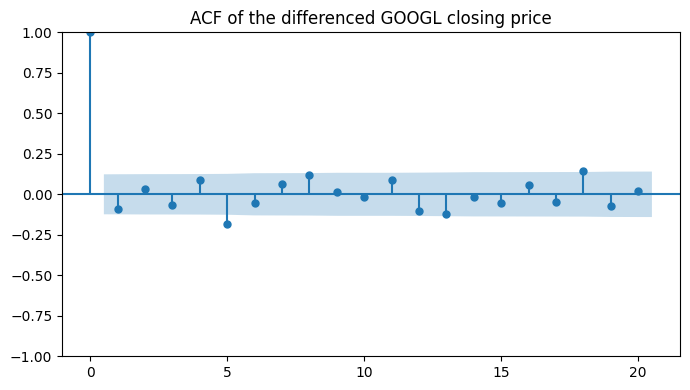

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_acf(diff_close, lags=20, ax=ax)
ax.set_title('ACF of the differenced GOOGL closing price')
plt.tight_layout()
plt.show()


**Figure 3.9** shows the ACF of the differenced GOOGL series. Reading it carefully:

- $r_0 = 1$, by construction (every series correlates perfectly with itself).
- Lags $1$ through $4$ are well inside the confidence band -- not significant.
- Lag $5$ pokes slightly above the band.
- Lag $18$ pokes slightly above the band.
- All other lags through $20$ are inside the band.

Are lags $5$ and $18$ real autocorrelations or are they spurious? With a $95\%$ confidence band, we expect about $1$ in $20$ lags to fall outside it *by chance* even when the true autocorrelation is exactly zero. Here we have $2$ out of $20$, which is consistent with random fluctuation, especially because:

- The two significant lags are isolated -- no consecutive run of significant coefficients suggesting genuine structure.
- The "significant" bars barely exceed the band; they would not survive a multiple-comparisons correction.

The standard interpretation -- followed by the textbook -- is that these are chance artifacts, not signal. **GOOGL closing price is therefore well-approximated by a random walk.**

This is a strong empirical claim. It says: knowing the entire history of GOOGL's daily close up to today gives you *no statistical leverage* on tomorrow's price beyond using today's close as your forecast. The implications for the forecasting strategy are stark, and we explore them in section 3.3.


## 3.3 Forecasting a random walk

If a process is a random walk, no statistical learning model can systematically beat the naive last-value forecast for the next timestep -- because the change is unforecastable by construction. This is not pessimism, it is theorem: $\mathbb E[\varepsilon_t \mid y_{t-1}, y_{t-2}, \dots] = 0$, so the optimal one-step-ahead point forecast under squared loss is $\hat y_t = y_{t-1}$.

This leaves us with two practical questions:

1. **How bad is forecasting on a long horizon?** If we have to predict not the next observation but the next $200$ observations, we cannot just repeat $y_{t-1}$ -- the prediction has to be a deterministic function of available data. We try three options: the historical mean, the last value, and a *drift* extrapolation.
2. **How good is forecasting on a one-step horizon?** When we are allowed to update our forecast each period using the most recent observation, the naive shift achieves essentially the white-noise floor -- and looks "too good to be true" on a plot.

We address both questions on the simulated random walk so the diagnostics stay clean.

### 3.3.1 Forecasting on a long horizon

Split the simulated walk into the first $800$ steps as training and the last $200$ as test.


In [17]:
df = pd.DataFrame({'value': random_walk})
train = df[:800]
test = df[800:]

print(f"Train: {len(train)} rows  (indices 0-799)")
print(f"Test:  {len(test)} rows  (indices 800-999)")
print(f"\nLast train value: {train.iloc[-1]['value']:.6f}")
print(f"First test value: {test.iloc[0]['value']:.6f}")


Train: 800 rows  (indices 0-799)
Test:  200 rows  (indices 800-999)

Last train value: -6.814947
First test value: -5.876664


The training set covers indices $0$ through $799$, ending at value $-6.8149$. The test set covers indices $800$ through $999$, $200$ steps to forecast. Visualize the split first.


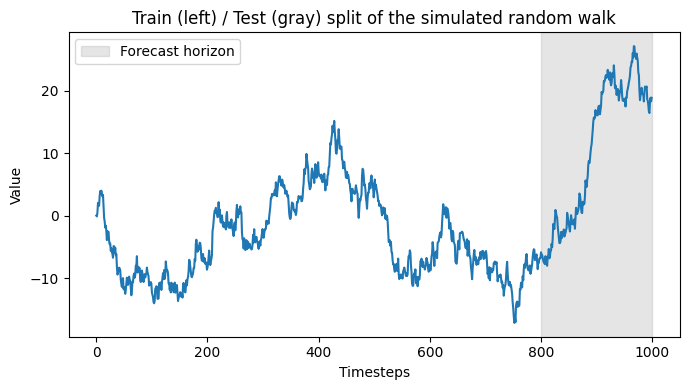

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(random_walk)
ax.axvspan(800, 1000, color='#808080', alpha=0.2, label='Forecast horizon')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('Train (left) / Test (gray) split of the simulated random walk')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Figure 3.10** marks the forecast horizon. From the look of the training data alone, what does a sensible long-horizon forecast look like? The walk had been declining sharply over the last $\sim 200$ training steps (from a peak near $+18$ down to about $-7$). Should we predict further decline? Mean reversion? A flat continuation?

This is exactly the situation where competing naive heuristics give very different answers, and the random-walk framework explains why none of them can be reliably right. We try three.

**Method 1: Historical mean.** Predict the train-set mean for every future step.


In [19]:
mean = np.mean(train['value'])
test.loc[:, 'pred_mean'] = mean
print(f"Train mean: {mean:.6f}")


Train mean: -3.677206


The historical mean is **$-3.6772$**. This is a flat prediction at $-3.6772$ for all $200$ future steps, the same kind of "central tendency" baseline we used in chapter 2.

**Method 2: Last known value.** Predict the last training observation for every future step.


In [20]:
last_value = train.iloc[-1]['value']
test.loc[:, 'pred_last'] = last_value
print(f"Last train value: {last_value:.6f}")


Last train value: -6.814947


The last training value is **$-6.8149$**, the value at index $799$. Note the difference: the historical mean ($-3.68$) is well above the last value ($-6.81$) because the walk spent much of its history at higher levels before declining. A "naive last" forecast bets that the recent regime continues; a "historical mean" forecast bets that the long-run average reasserts itself. With a random walk, both bets are equally indefensible -- and equally likely to be wrong by very different amounts.

**Method 3: The drift method.** This is new since chapter 2. The drift method fits a straight line between the first and last training observations and extrapolates that line forward. The slope is

$$\text{drift} = \frac{y_{\text{last}} - y_{\text{first}}}{n_{\text{train}} - 1}$$

and the forecast at horizon $h$ steps past the training set is

$$\hat y_{n + h} = y_{n} + h \cdot \text{drift}$$

This generalizes the random-walk-with-drift model: if we believe the underlying process has a nonzero $C$, the drift estimate gives us a maximum-likelihood-ish estimate of $C$.


In [21]:
deltaX = 800 - 1
deltaY = last_value - 0  # walk started at 0
drift = deltaY / deltaX

x_vals = np.arange(801, 1001, 1)
pred_drift = drift * x_vals
test.loc[:, 'pred_drift'] = pred_drift

print(f"deltaX (steps from index 0 to 799): {deltaX}")
print(f"deltaY (value change):              {deltaY:.6f}")
print(f"Drift (per step):                   {drift:.6f}")
print()
print("First 5 rows of test with all three predictions:")
print(test.head().round(6).to_string(index=True))


deltaX (steps from index 0 to 799): 799
deltaY (value change):              -6.814947
Drift (per step):                   -0.008529

First 5 rows of test with all three predictions:
        value  pred_mean  pred_last  pred_drift
800 -5.876664  -3.677206  -6.814947   -6.832006
801 -6.392708  -3.677206  -6.814947   -6.840536
802 -6.296588  -3.677206  -6.814947   -6.849065
803 -6.758863  -3.677206  -6.814947   -6.857594
804 -7.193359  -3.677206  -6.814947   -6.866124


The drift is **$-0.008529$** per step -- a small negative slope reflecting the fact that the walk ended below where it started. Extending this slope $200$ steps forward gives a forecast that slowly continues to decline: $-6.83$ at the first test step, drifting down to about $-8.53$ by the end. The drift method is essentially: "the trend you have seen so far will continue."

Plot all three forecasts against the actual test data.


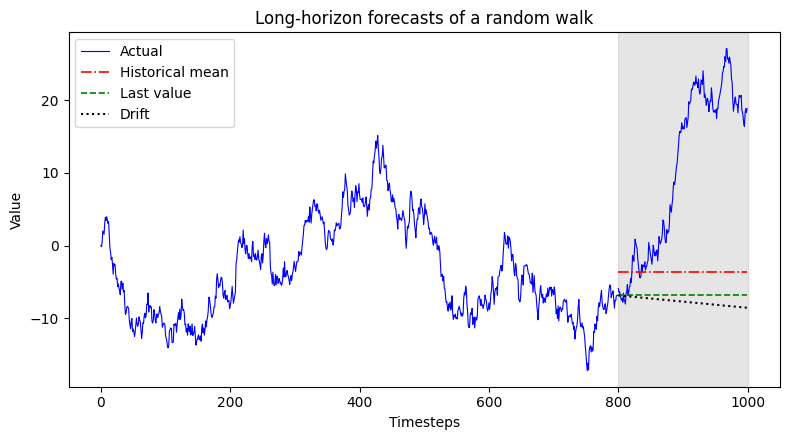

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(train['value'], 'b-', linewidth=0.8)
ax.plot(test['value'], 'b-', linewidth=0.8, label='Actual')
ax.plot(test['pred_mean'], 'r-.', label='Historical mean', linewidth=1.2)
ax.plot(test['pred_last'], 'g--', label='Last value', linewidth=1.2)
ax.plot(test['pred_drift'], 'k:', label='Drift', linewidth=1.5)
ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('Long-horizon forecasts of a random walk')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Figure 3.11** is the picture of failure. Around step $800$ the walk surprises us with a sharp **upward rally** -- exactly the kind of unforecastable regime change that random walks produce. All three baselines miss it badly:

- The **historical mean** (red dash-dot) sits at $-3.68$ -- below the actual values for most of the horizon.
- The **last value** (green dashed) sits at $-6.81$ -- even further below.
- The **drift** line (black dotted) continues the negative trend from training and ends up the *furthest* from the data, exactly opposite to what actually happened.

None of these is wrong because we picked the wrong baseline; they are all wrong because *the future change was unforecastable from the past*. Score them with mean squared error -- we cannot use MAPE because the random walk crosses zero, which would create division-by-zero in the percentage calculation.


In [23]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])

print(f"MSE (historical mean): {mse_mean:.4f}")
print(f"MSE (last value):      {mse_last:.4f}")
print(f"MSE (drift):           {mse_drift:.4f}")


MSE (historical mean): 326.5028
MSE (last value):      425.1726
MSE (drift):           466.2173


The MSEs are **$326.50$**, **$425.17$**, and **$466.22$**. Some perspective: the simulated walk has overall range roughly $25$ units (from $-7$ to $+18$), so an MSE of $\sim 300$ corresponds to a typical error magnitude of $\sqrt{326} \approx 18$ units -- the same order as the full range of the data. These are catastrophic forecasts.

The historical mean is the *least* bad of the three because it happens to land in the middle of the test range; the drift is the worst because it extrapolates a downward trend into a period where the actual series moved upward. But the ordering itself is a coincidence of the particular shock realizations -- a different random seed would reorder them.

A bar chart makes the relative magnitudes vivid.


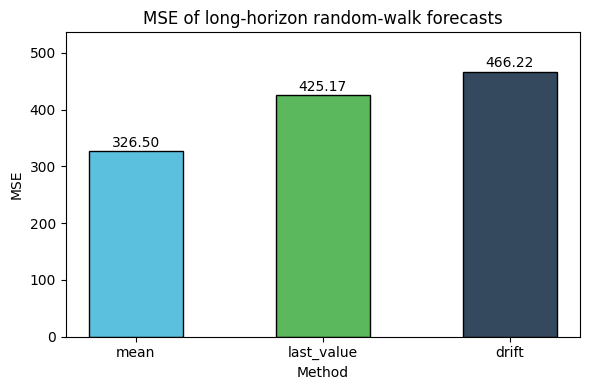

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['mean', 'last_value', 'drift']
values = [mse_mean, mse_last, mse_drift]
colors = ['#5bc0de', '#5cb85c', '#34495e']
bars = ax.bar(labels, values, width=0.5, color=colors, edgecolor='black')
ax.set_xlabel('Method')
ax.set_ylabel('MSE')
ax.set_title('MSE of long-horizon random-walk forecasts')
ax.set_ylim(0, max(values) * 1.15)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 8, f'{v:.2f}',
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()


**Figure 3.12** confirms the ranking: historical mean ($326.50$) beats last value ($425.17$), which beats drift ($466.22$). All three are bad. The lesson generalizes: **for a random walk, the longer the forecast horizon, the worse any deterministic forecast performs**, because the variance of the cumulative shock grows linearly with the horizon and no model can predict the trajectory of the shocks.

The practical implication: do not try to forecast a random-walk-like process more than one step ahead. If your application requires it, you should be forecasting *intervals* -- the prediction $\hat y_{t+h} = y_t$ with a confidence interval that widens as $\sqrt h$ -- not point estimates that pretend to know the future trajectory.

### 3.3.2 Forecasting the next timestep

When we forecast only *one step* ahead, and we re-observe the actual value before the next forecast, the picture changes completely. The naive "last value" forecast becomes essentially optimal: the prediction error at each step is just the next shock $\varepsilon_t$, whose variance is $1$ by construction. The MSE should be roughly $1$.

We implement one-step forecasting by simply *shifting* the series: at every index $t$, we predict the value observed at index $t-1$.


In [25]:
df_shift = df.shift(periods=1)
print("First 5 rows of the shifted series:")
print(df_shift.head().to_string())
print()
print("Original first 5 values:")
print(df.head().to_string())


First 5 rows of the shifted series:
      value
0       NaN
1  0.000000
2 -0.138264
3  0.509424
4  2.032454

Original first 5 values:
      value
0  0.000000
1 -0.138264
2  0.509424
3  2.032454
4  1.798301


The `shift(periods=1)` operation moves each value one row down. Row $0$ becomes NaN (we have no prior observation to use), row $1$ contains the value from row $0$ ($0.0$), row $2$ contains the value from row $1$ ($-0.1383$), and so on. This is the one-step naive forecast for the entire series.

Plot it against the actual series.


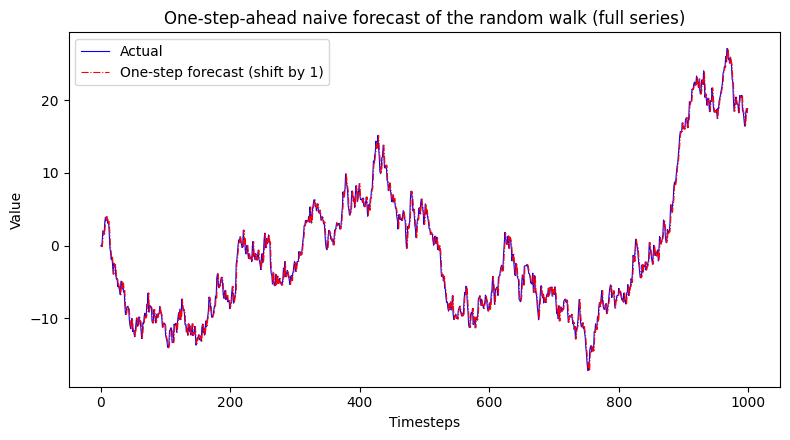

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df, 'b-', label='Actual', linewidth=0.8)
ax.plot(df_shift, 'r-.', label='One-step forecast (shift by 1)', linewidth=0.8)
ax.legend(loc='upper left')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('One-step-ahead naive forecast of the random walk (full series)')
plt.tight_layout()
plt.show()


**Figure 3.13** looks miraculous. The forecast (dash-dot) tracks the actual series (solid) so closely that the two lines are visually indistinguishable across the entire $1000$-step span. The MSE will be tiny.


In [27]:
mse_one_step = mean_squared_error(test['value'], df_shift[800:])
print(f"One-step naive forecast MSE on test set: {mse_one_step:.6f}")


One-step naive forecast MSE on test set: 0.925688


The MSE is **$0.9257$** -- two orders of magnitude better than any of the long-horizon baselines. This number is extraordinarily close to the theoretical white-noise variance of $1.0$, which is what we predicted: a one-step random-walk forecast error is just $\varepsilon_t \sim \mathcal N(0, 1)$, with expected squared error $1.0$. The realized $0.9257$ is within sampling noise of the theoretical optimum.

Before we declare victory, however, we should be honest about *what* we have predicted. Zoom into the last $100$ steps to see what the "forecast" really looks like up close.


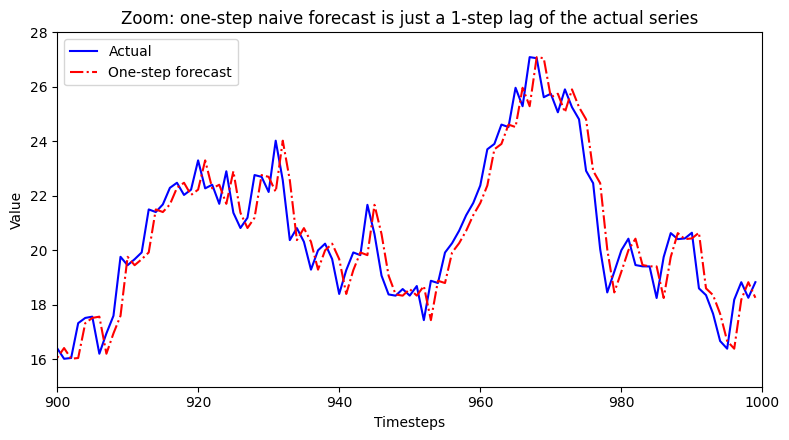

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df, 'b-', label='Actual', linewidth=1.5)
ax.plot(df_shift, 'r-.', label='One-step forecast', linewidth=1.5)
ax.set_xlim(900, 1000)
ax.set_ylim(15, 28)
ax.legend(loc='upper left')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.set_title('Zoom: one-step naive forecast is just a 1-step lag of the actual series')
plt.tight_layout()
plt.show()


**Figure 3.14** reveals the trick. Up close, the red "forecast" line is just the blue "actual" line **shifted one step to the right**. The forecast at step $t$ is identical to the actual value at step $t-1$. There is no anticipation of direction, no detection of trend reversal -- the model simply *waits to be told what happened* and reports that.

This is the random walk's revenge: the only way to get low forecast error is to barely forecast at all. A trader who acts on this kind of "forecast" is taking the position "tomorrow's price will be the same as today's" -- which gives them no edge over a buy-and-hold strategy.

**Lesson.** A low MSE on a one-step-ahead naive forecast is not evidence of a good model; it is evidence that the *process* is a random walk and that nothing can do better. Anyone presenting a backtest of a complex model whose MSE narrowly beats the naive shift on a financial series should be regarded with appropriate skepticism. The right benchmark is always: "does the model beat $\hat y_t = y_{t-1}$ in a statistically significant sense, on out-of-sample data, accounting for transaction costs?"

If the answer is no, the process is a random walk and you should not be modeling it.


## 3.4 Summary and next steps

This chapter equipped us with the diagnostic infrastructure that every subsequent chapter assumes.

**Concepts introduced**:

- **Random walk**: $y_t = C + y_{t-1} + \varepsilon_t$. The first difference is stationary white noise; the level is non-stationary.
- **Stationarity**: a series whose mean, variance, and autocorrelation structure are time-invariant. Most parametric forecasting models require it.
- **Differencing**: $y'_t = y_t - y_{t-1}$. The standard transformation to remove a trend (or to produce a stationary random-walk increment from a random-walk level).
- **Log transform**: stabilizes variance when amplitude scales with level. Particularly useful for prices, populations, GDP.
- **Augmented Dickey-Fuller (ADF) test**: $H_0$: unit root present; $H_1$: stationary. Reject $H_0$ when the ADF statistic is sufficiently negative or $p < 0.05$.
- **Autocorrelation function (ACF)**: $r_k = \text{Corr}(y_t, y_{t-k})$ plotted against $k$. Slow decay $\Rightarrow$ non-stationarity; no significant lags $\Rightarrow$ white noise.
- **Four-step random-walk diagnostic**: gather $\to$ ADF on raw $\to$ difference if non-stationary $\to$ ADF + ACF on differenced.

**Empirical findings**:

- Simulated random walk: raw ADF $= -0.97$, $p = 0.77$ (non-stationary). Differenced ADF $= -31.79$, $p \approx 0$ (stationary). Differenced ACF: no significant lags. $\Rightarrow$ Random walk confirmed.
- GOOGL closing price (Apr $2020$ - Apr $2021$): raw ADF $= 0.16$, $p = 0.97$ (non-stationary). Differenced ADF $= -5.30$, $p \approx 5 \times 10^{-6}$ (stationary). Differenced ACF: lags $5$ and $18$ marginally significant but assumed to be chance. $\Rightarrow$ Approximately a random walk.

**Forecasting findings**:

- Long horizon ($200$ steps): historical mean, last value, drift all fail catastrophically with MSEs of $326.50$, $425.17$, $466.22$. No deterministic forecast can succeed on a random walk over a long horizon.
- One-step horizon: the naive shift achieves MSE $= 0.9257$, near the theoretical white-noise floor of $1.0$. But this "good" forecast is just a lagged copy of the actual series.

**The strategic implication.** If a process is a random walk, *do not build a complex model for it*. Use $\hat y_t = y_{t-1}$ and quantify the uncertainty with $\sqrt{h}$-widening prediction intervals. Spend your modeling budget on processes that are *not* random walks -- where there is exploitable structure in the autocorrelation.

### Coming up: chapter 4

What if the differenced series is stationary *but* shows a clear pattern of significant autocorrelation at low lags, then cuts off sharply? That is the signature of a **moving average (MA) process** -- the simplest parametric model that exhibits genuine forecastable structure. Chapter 4 will:

- Define the MA($q$) model: $y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \ldots + \theta_q \varepsilon_{t-q}$.
- Show how to identify the order $q$ from the ACF.
- Walk through fitting an MA model with `statsmodels`.
- Forecast and compare against the naive seasonal benchmark of MAPE $= 11.56\%$ that we carried over from chapter 2.

### Summary bullets

- A random walk is a sequence whose **first difference is stationary and uncorrelated**.
- Use **statistical or machine learning models only when the process is not a random walk** -- otherwise the naive forecast is provably optimal.
- A stationary series has time-invariant mean, variance, and autocorrelation.
- The **ADF test** detects non-stationarity by testing for a unit root; reject $H_0$ when the statistic is sufficiently negative and $p < 0.05$.
- **Differencing** stabilizes the trend; **log transforms** stabilize the variance.
- The **ACF** plots autocorrelation as a function of lag; on white noise it has no significant non-zero lags.
- Forecast random walks in the **short term only** -- accumulated noise destroys long-horizon forecasts.
